In [ ]:
import pandas as pd

df = pd.read_csv("../data/hotel_bookings.csv")

print(df.shape)

df.head()

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
df = df.drop(['company'], axis=1)

In [7]:
df['agent'] = df['agent'].fillna(0)

In [8]:
df['children'] = df['children'].fillna(0)

In [9]:
df['country'] = df['country'].fillna('Unknown')

In [10]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [11]:
df['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

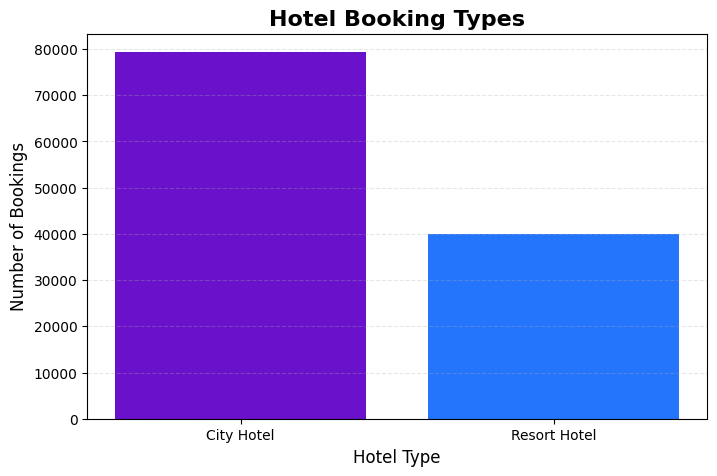

In [13]:
import matplotlib.pyplot as plt

hotel_counts = df['hotel'].value_counts()

colors = ['#6a11cb', '#2575fc']

plt.figure(figsize=(8,5))

bars = plt.bar(
    hotel_counts.index,
    hotel_counts.values,
    color=colors
)

plt.title("Hotel Booking Types", fontsize=16, fontweight='bold')
plt.xlabel("Hotel Type", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [14]:
monthly_bookings = df['arrival_date_month'].value_counts()

monthly_bookings

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

In [15]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_bookings = df['arrival_date_month'].value_counts()

monthly_bookings = monthly_bookings.reindex(month_order)

monthly_bookings

arrival_date_month
January       5929
February      8068
March         9794
April        11089
May          11791
June         10939
July         12661
August       13877
September    10508
October      11160
November      6794
December      6780
Name: count, dtype: int64

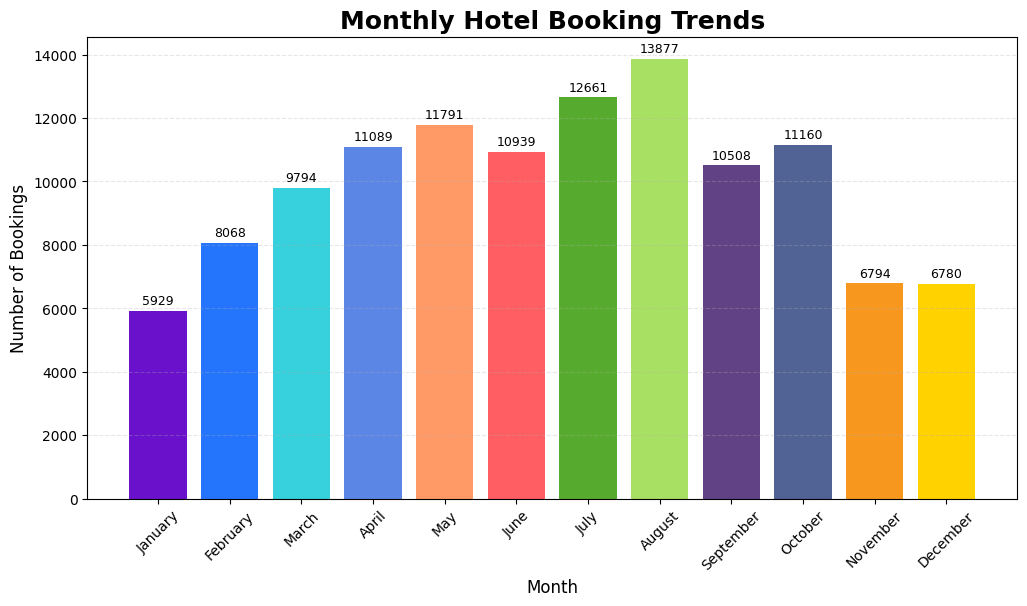

In [16]:
import matplotlib.pyplot as plt

colors = [
    '#6a11cb', '#2575fc', '#36d1dc', '#5b86e5',
    '#ff9966', '#ff5e62', '#56ab2f', '#a8e063',
    '#614385', '#516395', '#f7971e', '#ffd200'
]

plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_bookings.index,
    monthly_bookings.values,
    color=colors
)

plt.title(
    "Monthly Hotel Booking Trends",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 200,
        int(yval),
        ha='center',
        fontsize=9
    )

plt.show()

In [17]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [18]:
cancel_percentage = df['is_canceled'].value_counts(normalize=True) * 100

cancel_percentage

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

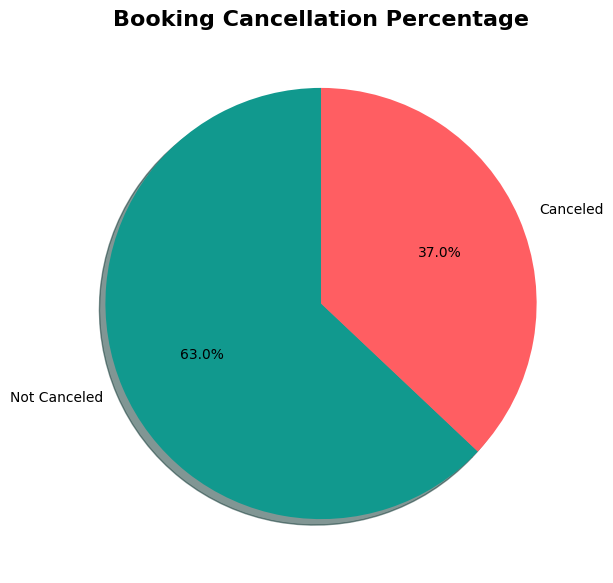

In [19]:
import matplotlib.pyplot as plt

cancel_percentage = df['is_canceled'].value_counts(normalize=True) * 100

labels = ['Not Canceled', 'Canceled']

colors = ['#11998e', '#ff5e62']

plt.figure(figsize=(7,7))

plt.pie(
    cancel_percentage,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True
)

plt.title(
    "Booking Cancellation Percentage",
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [20]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [22]:
df = df[df['adr'] < 500]

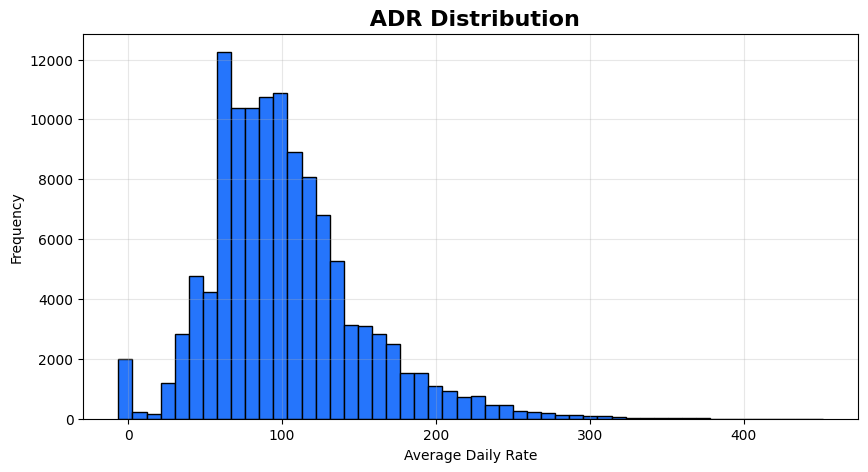

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df['adr'],
    bins=50,
    color='#2575fc',
    edgecolor='black'
)

plt.title(
    " ADR Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [26]:
hotel_adr = df.groupby('hotel')['adr'].mean()

hotel_adr

hotel
City Hotel      105.232620
Resort Hotel     94.942619
Name: adr, dtype: float64

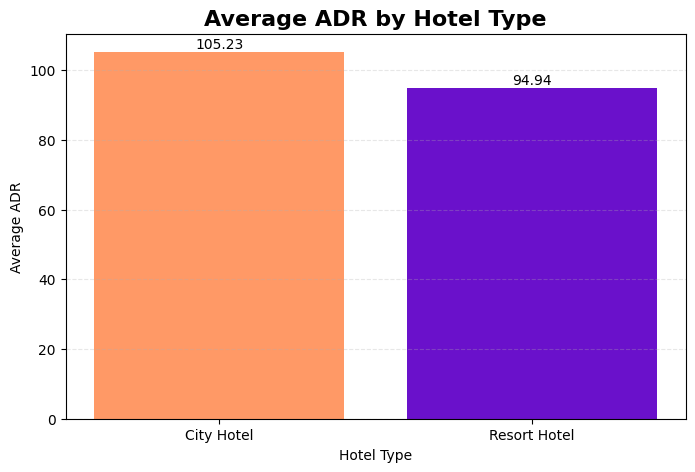

In [27]:
import matplotlib.pyplot as plt

colors = ['#ff9966', '#6a11cb']

plt.figure(figsize=(8,5))

bars = plt.bar(
    hotel_adr.index,
    hotel_adr.values,
    color=colors
)

plt.title(
    "Average ADR by Hotel Type",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        round(yval, 2),
        ha='center'
    )

plt.show()

In [28]:
top_countries = df['country'].value_counts().head(10)

top_countries

country
PRT    48588
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3765
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

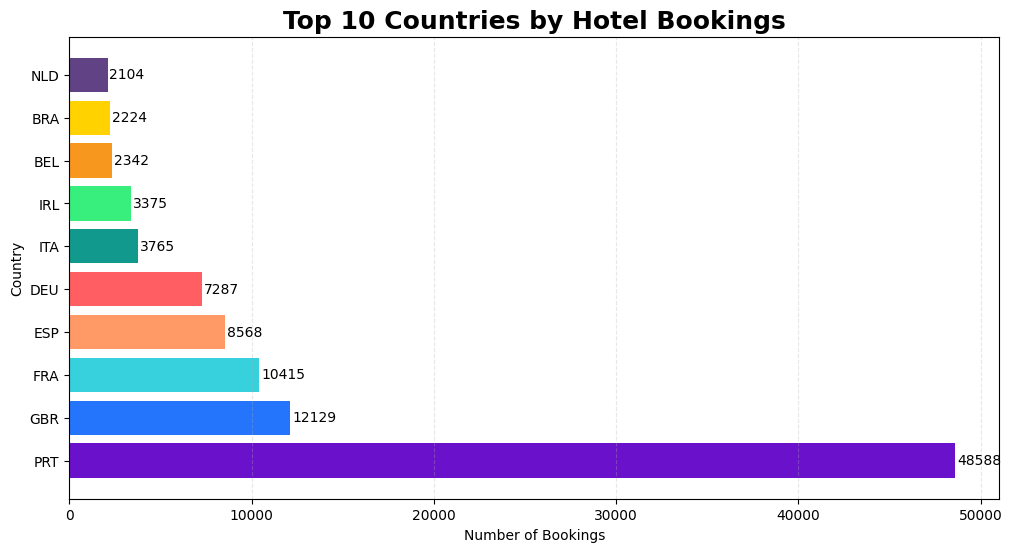

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

colors = [
    '#6a11cb', '#2575fc', '#36d1dc',
    '#ff9966', '#ff5e62', '#11998e',
    '#38ef7d', '#f7971e', '#ffd200',
    '#614385'
]

bars = plt.barh(
    top_countries.index,
    top_countries.values,
    color=colors
)

plt.title(
    "Top 10 Countries by Hotel Bookings",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Bookings")
plt.ylabel("Country")

plt.grid(axis='x', linestyle='--', alpha=0.3)

for bar in bars:
    xval = bar.get_width()
    plt.text(
        xval + 100,
        bar.get_y() + bar.get_height()/2,
        int(xval),
        va='center'
    )

plt.show()

In [30]:
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100

cancel_by_hotel

hotel
City Hotel      41.726755
Resort Hotel    27.764048
Name: is_canceled, dtype: float64

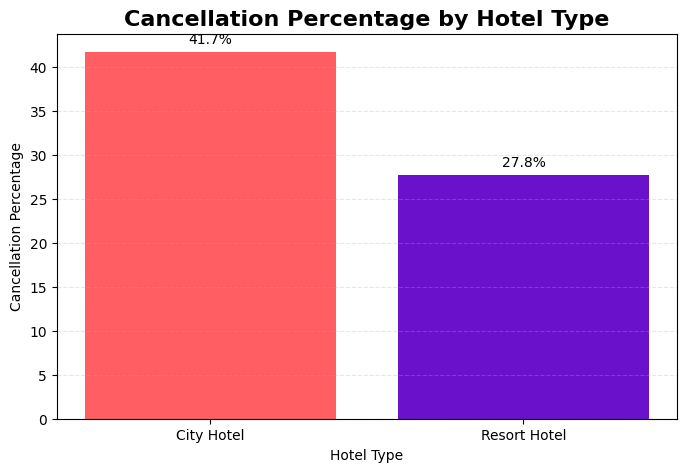

In [31]:
import matplotlib.pyplot as plt

colors = ['#ff5e62', '#6a11cb']

plt.figure(figsize=(8,5))

bars = plt.bar(
    cancel_by_hotel.index,
    cancel_by_hotel.values,
    color=colors
)

plt.title(
    "Cancellation Percentage by Hotel Type",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Percentage")

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        f"{yval:.1f}%",
        ha='center'
    )

plt.show()

In [32]:
df.to_csv("../data/cleaned_hotel_bookings.csv", index=False)

In [33]:
import sqlite3

conn = sqlite3.connect('../hotel_bookings.db')

df.to_sql(
    'hotel_bookings',
    conn,
    if_exists='replace',
    index=False
)

print("Database created successfully!")

Database created successfully!
